In [2]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [1]:
###### the spreading of failures
import sys
import pickle,itertools
import copy
import os

import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
import pypsa
import pandas as pd

#date_string = datetime.datetime.now().strftime("%I_%M_%B_%d")

path = '/media/fkaiser/'

sys.path.append('../power_system_split/')
import utils,visualisation

# Evaluate component cluster for single CO$_2$ level

In [12]:
co2l = 0.1

path_to_pypsa_network   = path + 'Data/system_split/European_Networks/New_networks_CO2_levels/'
results_path = path + 'Data/system_split/European_Networks/New_networks_CO2_levels/Results/'

network = pypsa.Network()
network.import_from_netcdf(path_to_pypsa_network+'elec_s_800_ec_lv1.0_Co2L%.1f-3H.nc'%co2l) # +year+'/elec_s_306_ec_lv1.0_1H.nc')#

G = utils.build_networkx_graph(network, snet_index=0)


splitting_cascades = pickle.load(open(results_path+'system_splits_Co2L%.1f.pickle' % (co2l),'rb'))

solution_dict = pickle.load(open(results_path+'Europe_Co2L%.1f_split_evaluation_load_based.pickle'%co2l,'rb'))

indicator_vectors, component_props = visualisation.indicator_vectors_from_rocof_solution(solution_dict, splitting_cascades, G, criterion='load')



/media/jkruse/Projects/system_splits/power-system-split/venv/lib/python3.7/site-packages/pypsa/io.py:769: FutureWarning: Index.__or__ operating as a set operation is deprecated, in the future this will be a logical operation matching Series.__or__.  Use index.union(other) instead
  pnl[attr] = pnl[attr].reindex(columns=df.index | columns, fill_value=default)
/media/jkruse/Projects/system_splits/power-system-split/venv/lib/python3.7/site-packages/pypsa/io.py:771: FutureWarning: Index.__or__ operating as a set operation is deprecated, in the future this will be a logical operation matching Series.__or__.  Use index.union(other) instead
  pnl[attr] = pnl[attr].reindex(columns=(pnl[attr].columns | columns))
INFO:pypsa.io:Imported network elec_s_800_ec_lv1.0_Co2L0.1-3H.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units


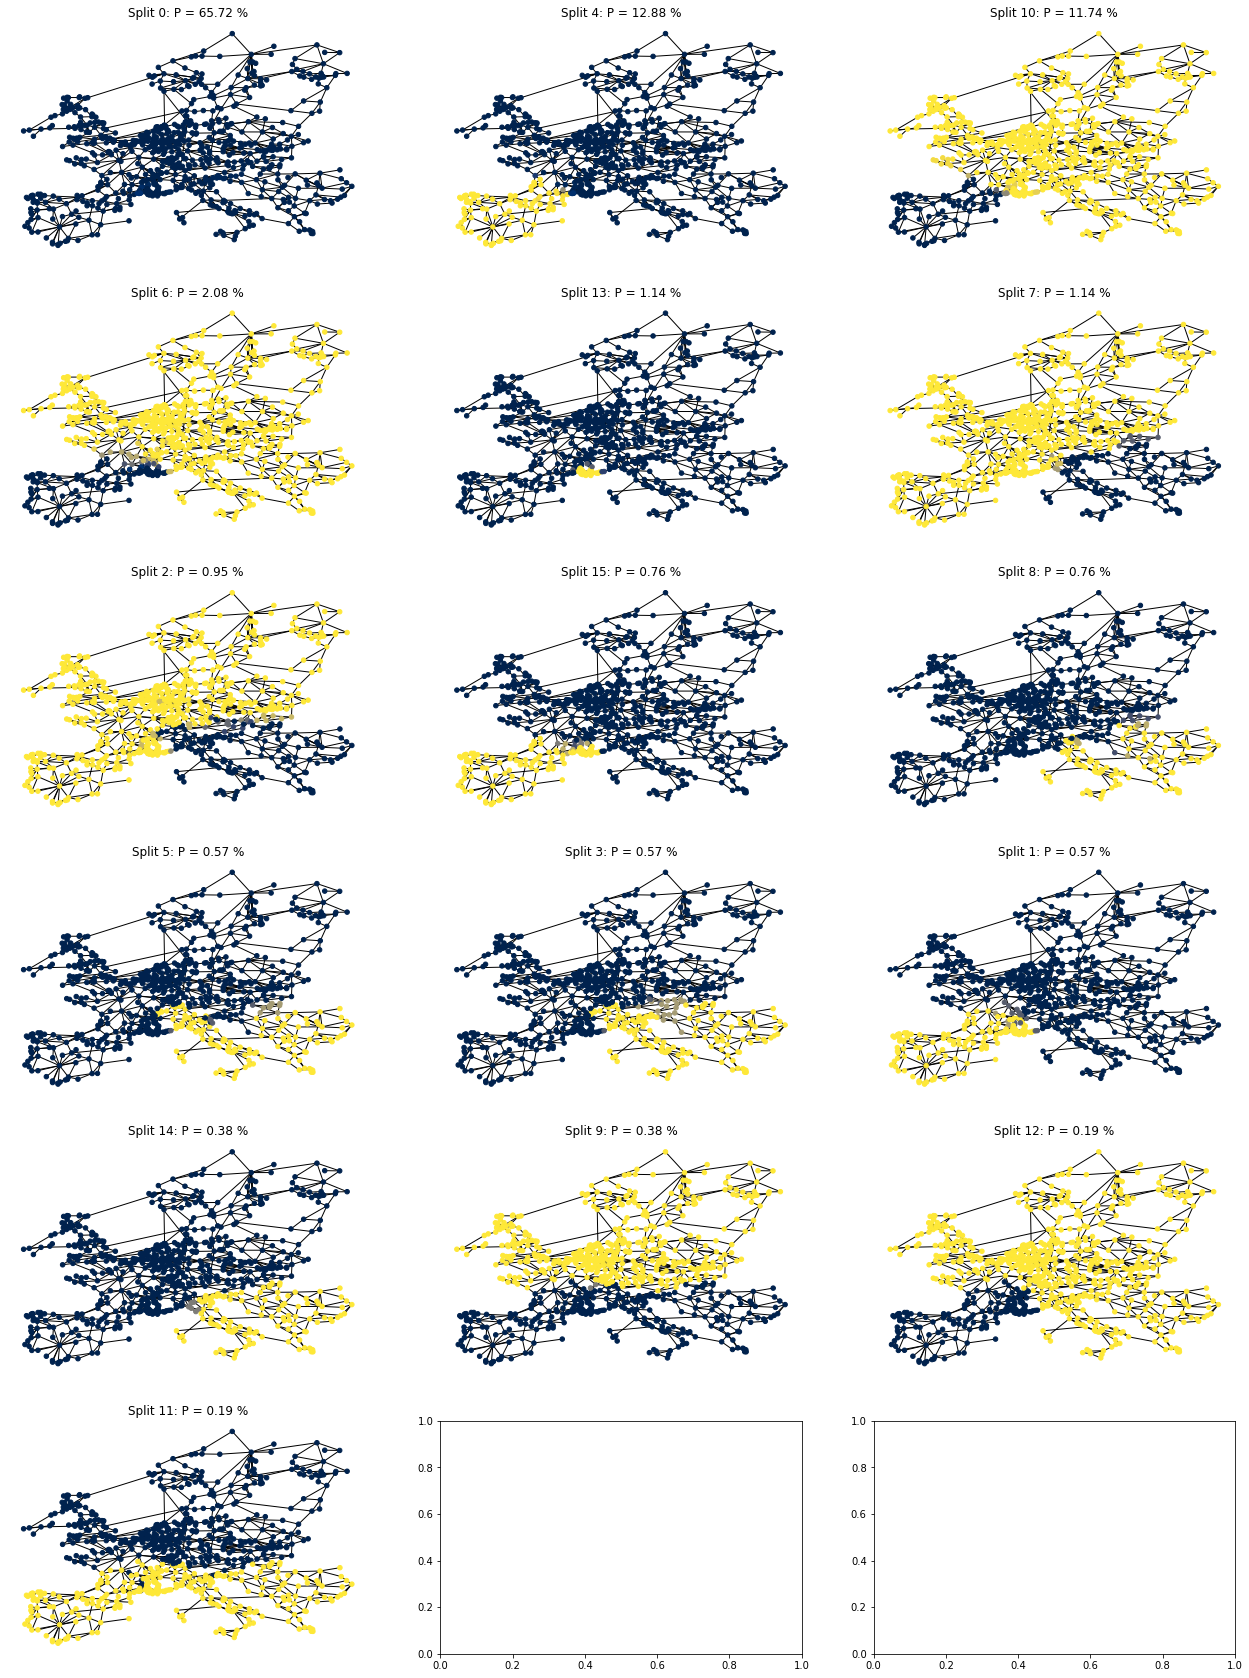

In [18]:
min_cluster_distance = 20./ len(G.nodes())
n_cluster, cluster_labels = visualisation.cluster_indicator_vectors(indicator_vectors, min_cluster_distance=min_cluster_distance)

n_cols = 3
n_rows = np.ceil(n_cluster/n_cols).astype(int)
fig,ax = plt.subplots(n_rows,n_cols,figsize=(22,30))

visualisation.plot_component_cluster(indicator_vectors, ax.flatten()[:n_cluster],
                                     cluster_labels, G)

In [ ]:
component_props.loc[:,'rocof'] = component_props.load_imbalance / component_props.inertia_proxy
component_props.loc[:, 'cluster_label'] = cluster_labels

In [212]:
# how to deal with infinite rocof/ zero inertia ? does it occur?
bridges = list(nx.bridges(nx.Graph(G)))
non_bridges = list(set(list(G.edges())) - set(bridges))

number_of_simulations = len(non_bridges)*len(solution_dict.keys())

cluster_props = component_props.groupby('cluster_label').size().to_frame('counts')
cluster_props.loc[:,'likelihood'] = cluster_props.counts.div(number_of_simulations)
cluster_props.loc[:,'mean_number_of_nodes'] = split_component_results.groupby('cluster_label')['number_of_nodes'].mean()
cluster_props.loc[:,'mean_rocof'] = split_component_results.groupby('cluster_label')['rocof'].mean()
cluster_props.loc[:,'median_rocof'] = split_component_results.groupby('cluster_label')['rocof'].median()
cluster_props.loc[:,'min_rocof'] = split_component_results.groupby('cluster_label')['rocof'].min()
cluster_props.loc[:,'mmax_rocof'] = split_component_results.groupby('cluster_label')['rocof'].max()
cluster_props

,counts,likelihood,mean_number_of_nodes,mean_rocof
cluster_label,,,,
0.0,26,9.313922e-06,88.538462,2.961028
1.0,26,9.313922e-06,513.923077,2.673681
2.0,11,3.940506e-06,451.545455,0.183376
3.0,274,9.815441e-05,2.029197,2.375328
4.0,11,3.940506e-06,63.272727,5.377162
5.0,12,4.298733e-06,61.666667,144.823643
7.0,1,3.582278e-07,362.000000,3.664409


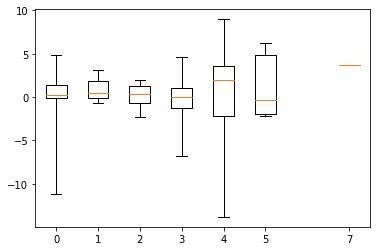

In [211]:
_= plt.boxplot(split_component_results.groupby('cluster_label')['rocof'].apply(list).values,
               positions=component_likelihoods.index,
               showfliers=False,
               whis=[10,90])

In [ ]:
#check if min and max rocof are in the right order for + and - error
plt.errorbar(x=cluster_props.likelihood, y=cluster_props.median_rocof,
             yerr= (cluster_props.loc[:,['min_rocof', 'max_rocof']]-cluster_props.median_rocof).T)
plt.xscale('log')
#plt.yscale('log')

# Evaluate component cluster for CO$_2$ levels together

In [ ]:
component_props = pd.DataFrame()
indicator_vectors = np.array([])

for co2l in [0.1, 0.2, 0.3, 0.4, 0.5]:

    path_to_pypsa_network   = path + 'Data/system_split/European_Networks/New_networks_CO2_levels/'
    results_path = path + 'Data/system_split/European_Networks/New_networks_CO2_levels/Results/'

    network = pypsa.Network()
    network.import_from_netcdf(path_to_pypsa_network+'elec_s_800_ec_lv1.0_Co2L%.1f-3H.nc'%co2l) # +year+'/elec_s_306_ec_lv1.0_1H.nc')#

    G = utils.build_networkx_graph(network, snet_index=0)


    splitting_cascades = pickle.load(open(results_path+'system_splits_Co2L%.1f.pickle' % (co2l),'rb'))

    solution_dict = pickle.load(open(results_path+'Europe_Co2L%.1f_split_evaluation_load_based.pickle'%co2l,'rb'))

    indicator_vectors_co2level, component_props_co2level = visualisation.indicator_vectors_from_rocof_solution(solution_dict, splitting_cascades, G, criterion='load')

    # append ind vectors and component_props



In [ ]:
# cluster all indicator vectors

In [ ]:
# display clusters

In [ ]:
# display likelihood of cluster "i" depending on co2 level
# display risk of cluster "i" (e.g. median rocof +/- min-max or qunatiles) depending on co2 level